# NYC Bus Processed Data Analysis
This notebook loads the processed congestion pricing datasets, reproduces the core visualizations, and reruns the difference-in-differences regression using the same logic as the main pipeline.

---
# Environment Setup
Installing necessary packages

In [15]:
# %pip install sodapy
# %pip install geopandas
# %pip install ipywidgets
# %pip install tqdm
# %pip install folium
# %pip install scikit-learn
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Loading the necessary packages

In [16]:
import os
import json
import time
from pathlib import Path
from datetime import datetime

import pandas as pd
import geopandas as gpd
import numpy as np
import shapely

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import folium
from folium.plugins import MarkerCluster

from IPython.display import display

from sodapy import Socrata
import requests
import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

env = os.environ
plt.style.use("seaborn-v0_8")

---
## Data Files and Loading Workflow
We will point to the processed CSV outputs generated by the pipeline and cache their paths for quick reuse.

In [17]:
# Define core directories for processed and raw artifacts
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "Data").exists():
    raise FileNotFoundError("Could not locate the 'Data' directory relative to the notebook.")
DATA_DIR = PROJECT_ROOT / "Data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"
REPORTS_DIR = PROJECT_ROOT / "reports"
print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")

Project root: /Users/kaspar/Documents/_Documents/Data_Science/Bus Project Data Science
Processed data directory: /Users/kaspar/Documents/_Documents/Data_Science/Bus Project Data Science/Data/processed

Processed data directory: /Users/kaspar/Documents/_Documents/Data_Science/Bus Project Data Science/Data/processed


In [40]:
# Load the processed datasets that feed the visualizations
segment_speed_cols = [
    "year","month","timestamp","route_id","route_type","hour_of_day","weekend",
    "weight_distance","weight_travel_time", "average_road_speed", "timepoint_stop_latitude","timepoint_stop_longitude"
]
segment_speed = pd.read_csv(PROCESSED_DIR / "segment_speed_processed.csv", usecols=segment_speed_cols)
ridership = pd.read_csv(PROCESSED_DIR / "ridership_processed.csv")
cbd_entries = pd.read_csv(PROCESSED_DIR / "cbd_entries_processed.csv", parse_dates=["toll_date", "toll_hour"])
cbd_routes = pd.read_csv(RAW_DIR / "MTA_CBD_Bus_Routes_2025_20251105.csv")
print(f"Segment speed rows: {len(segment_speed):,}")
print(f"Ridership rows: {len(ridership):,}")
print(f"CBD crossings rows: {len(cbd_entries):,}")
print(f"CBD route lookup rows: {len(cbd_routes):,}")

Segment speed rows: 2,221,909
Ridership rows: 1,113,936
CBD crossings rows: 2,975,616
CBD route lookup rows: 107


### Quick dataset summaries
The following snippets mirror the exploratory checks from the original analysis notebook to confirm row counts and column coverage.

In [41]:
def describe_frame(name: str, frame: pd.DataFrame, n: int = 3) -> None:
    """Display key stats for a dataframe, mirroring the prior EDA notebook."""
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Rows: {len(frame):,} | Columns: {len(frame.columns)}")
    print("Columns:", ", ".join(frame.columns[:10]) + ("..." if len(frame.columns) > 10 else ""))
    display(frame.head(n))

describe_frame("Segment speeds (processed)", segment_speed)
describe_frame("Ridership (processed)", ridership)
describe_frame("CBD toll plaza entries", cbd_entries)
describe_frame("CBD route lookup", cbd_routes)


Segment speeds (processed)
--------------------------
Rows: 2,221,909 | Columns: 12
Columns: year, month, timestamp, hour_of_day, route_id, route_type, timepoint_stop_latitude, timepoint_stop_longitude, average_road_speed, weight_distance...


,year,month,timestamp,hour_of_day,route_id,route_type,timepoint_stop_latitude,timepoint_stop_longitude,average_road_speed,weight_distance,weight_travel_time,weekend
0,2025,3,2025 Mar 01 12:00:00 PM,12,M11,Local,40.819614,-73.954283,5.760523,8.820,1.531112,0
1,2025,3,2025 Mar 01 03:00:00 PM,15,M50,Local,40.758431,-73.977104,2.635110,6.000,2.276945,0
2,2025,3,2025 Mar 01 11:00:00 PM,23,M11,Local,40.819614,-73.954283,10.410519,0.882,0.084722,0



Ridership (processed)
---------------------
Rows: 1,113,936 | Columns: 9
Columns: transit_timestamp, bus_route, total_ridership, year, month, day, hour, day_of_week, weekend


,transit_timestamp,bus_route,total_ridership,year,month,day,hour,day_of_week,weekend
0,2025-01-01 00:00:00,M1,36,2025,1,1,0,Wednesday,0
1,2025-01-01 00:00:00,M10,23,2025,1,1,0,Wednesday,0
2,2025-01-01 00:00:00,M100,15,2025,1,1,0,Wednesday,0



CBD toll plaza entries
----------------------
Rows: 2,975,616 | Columns: 18
Columns: toll_date, toll_hour, toll_10_minute_block, minute_of_hour, hour, day_of_week_int, day_of_week, toll_week, time_period, vehicle_class...


,toll_date,toll_hour,toll_10_minute_block,minute_of_hour,hour,day_of_week_int,day_of_week,toll_week,time_period,vehicle_class,detection_group,detection_region,sum_crz_entries,excluded_roadway_entries,year,month,day,weekend
0,2025-10-18,2025-10-18 23:00:00,2025-10-18T23:50:00.000,50,23,7,Saturday,2025-10-12T00:00:00.000,Overnight,5 - Motorcycles,Queens Midtown Tunnel,Queens,1,0,2025,10,18,1
1,2025-10-18,2025-10-18 23:00:00,2025-10-18T23:50:00.000,50,23,7,Saturday,2025-10-12T00:00:00.000,Overnight,3 - Multi-Unit Trucks,Brooklyn Bridge,Brooklyn,0,0,2025,10,18,1
2,2025-10-18,2025-10-18 23:00:00,2025-10-18T23:50:00.000,50,23,7,Saturday,2025-10-12T00:00:00.000,Overnight,3 - Multi-Unit Trucks,Hugh L. Carey Tunnel,Brooklyn,0,0,2025,10,18,1



CBD route lookup
----------------
Rows: 107 | Columns: 2
Columns: route_id, cbd_relation


,route_id,cbd_relation
0,BM1,Crossing CBD
1,BM2,Crossing CBD
2,BM3,Crossing CBD


---
## Peak-Hour Speed Trends
We mirror the curated transforms used in the pipeline: focus on Manhattan local routes, restrict to weekday peak hours, and compute weighted average speeds by month.

In [42]:
# Prepare a Manhattan-focused, weekday peak-hour panel with CBD labels
PEAK_HOURS = {7, 8, 9, 10, 16, 17, 18, 19}
cbd_routes_clean = cbd_routes.assign(
    route_id=cbd_routes["route_id"].astype(str).str.upper().str.strip(),
    cbd_relation=cbd_routes["cbd_relation"].astype(str).str.strip()
 )
cbd_in_routes = set(cbd_routes_clean.loc[cbd_routes_clean["cbd_relation"].str.lower() == "in cbd", "route_id"])
manhattan_peak = (
    segment_speed.assign(
        route_id=lambda df: df["route_id"].astype(str).str.upper().str.strip(),
        month=lambda df: pd.to_numeric(df["month"], errors="coerce"),
        year=lambda df: pd.to_numeric(df["year"], errors="coerce")
    )
    .dropna(subset=["month", "year", "average_road_speed", "weight_distance", "timepoint_stop_latitude", "timepoint_stop_longitude"])
    .assign(
        month=lambda df: df["month"].astype(int),
        year=lambda df: df["year"].astype(int)
    )
    .query("route_id.str.startswith('M')", engine="python")
    .loc[lambda df: df["weekend"] == 0]
    .loc[lambda df: df["hour_of_day"].isin(PEAK_HOURS)]
    .copy()
 )
manhattan_peak["weight_distance"] = manhattan_peak["weight_distance"].clip(lower=0.0001)
manhattan_peak["weighted_speed"] = manhattan_peak["average_road_speed"] * manhattan_peak["weight_distance"]
manhattan_peak["treatment"] = manhattan_peak["route_id"].isin(cbd_in_routes).astype(int)
manhattan_peak["group"] = np.where(manhattan_peak["treatment"] == 1, "CBD routes", "Manhattan non-CBD")
manhattan_peak["month_start"] = pd.to_datetime(dict(year=manhattan_peak["year"], month=manhattan_peak["month"], day=1))
print(f"Filtered peak panel rows: {len(manhattan_peak):,}")
manhattan_peak.head()

Filtered peak panel rows: 618,269


,year,month,timestamp,hour_of_day,route_id,route_type,timepoint_stop_latitude,timepoint_stop_longitude,average_road_speed,weight_distance,weight_travel_time,weekend,weighted_speed,treatment,group,month_start
5,2025,3,2025 Mar 01 05:00:00 PM,17,M11,Local,40.819614,-73.954283,6.104589,6.615,1.083611,0,40.381858,0,Manhattan non-CBD,2025-03-01
7,2025,3,2025 Mar 01 07:00:00 AM,7,M4,Local,40.820642,-73.954489,5.352497,14.028,2.620834,0,75.084824,0,Manhattan non-CBD,2025-03-01
11,2025,3,2025 Mar 01 07:00:00 AM,7,M50,Local,40.758431,-73.977104,5.078469,8.000,1.575278,0,40.627750,1,CBD routes,2025-03-01
12,2025,3,2025 Mar 01 06:00:00 PM,18,M11,Local,40.819614,-73.954283,5.725772,4.851,0.847222,0,27.775720,0,Manhattan non-CBD,2025-03-01
14,2025,3,2025 Mar 01 10:00:00 AM,10,M11,Local,40.819614,-73.954283,5.641789,8.820,1.563334,0,49.760576,0,Manhattan non-CBD,2025-03-01


In [21]:
monthly_panel = (
    manhattan_peak.groupby(["route_id", "month_start", "treatment", "group"], as_index=False)
    .agg(
        total_distance=("weight_distance", "sum"),
        weighted_speed=("weighted_speed", "sum")
    )
)
monthly_panel["avg_speed_mph"] = monthly_panel["weighted_speed"] / monthly_panel["total_distance"]
monthly_panel["year"] = monthly_panel["month_start"].dt.year
monthly_panel["month_num"] = monthly_panel["month_start"].dt.month
monthly_panel.sort_values(["route_id", "month_start"], inplace=True)
monthly_panel.head()

,route_id,month_start,treatment,group,total_distance,weighted_speed,avg_speed_mph,year,month_num
0,M1,2023-01-01,0,Manhattan non-CBD,14006.373,83243.550236,5.943262,2023,1
1,M1,2023-02-01,0,Manhattan non-CBD,13329.260,78541.204923,5.892390,2023,2
2,M1,2023-03-01,0,Manhattan non-CBD,15225.711,88973.907738,5.843662,2023,3
3,M1,2023-04-01,0,Manhattan non-CBD,13367.234,76818.017454,5.746740,2023,4
4,M1,2023-05-01,0,Manhattan non-CBD,14846.677,85071.492115,5.730002,2023,5


In [22]:
group_monthly = (
    monthly_panel.groupby(["group", "month_start"], as_index=False)
    .agg(
        total_distance=("total_distance", "sum"),
        weighted_speed=("weighted_speed", "sum")
    )
)
group_monthly["avg_speed_mph"] = group_monthly["weighted_speed"] / group_monthly["total_distance"]
overall_monthly = (
    monthly_panel.groupby(["month_start"], as_index=False)
    .agg(
        total_distance=("total_distance", "sum"),
        weighted_speed=("weighted_speed", "sum")
    )
)
overall_monthly["avg_speed_mph"] = overall_monthly["weighted_speed"] / overall_monthly["total_distance"]
overall_monthly["group"] = "Manhattan all routes"
group_monthly = pd.concat([group_monthly, overall_monthly], ignore_index=True)
group_monthly.head()

,group,month_start,total_distance,weighted_speed,avg_speed_mph
0,CBD routes,2023-01-01,51902.673,299226.924561,5.765154
1,CBD routes,2023-02-01,46923.240,267527.129732,5.701378
2,CBD routes,2023-03-01,54850.420,310070.222820,5.653015
3,CBD routes,2023-04-01,48293.709,276445.196292,5.724249
4,CBD routes,2023-05-01,54633.535,309135.968136,5.658356


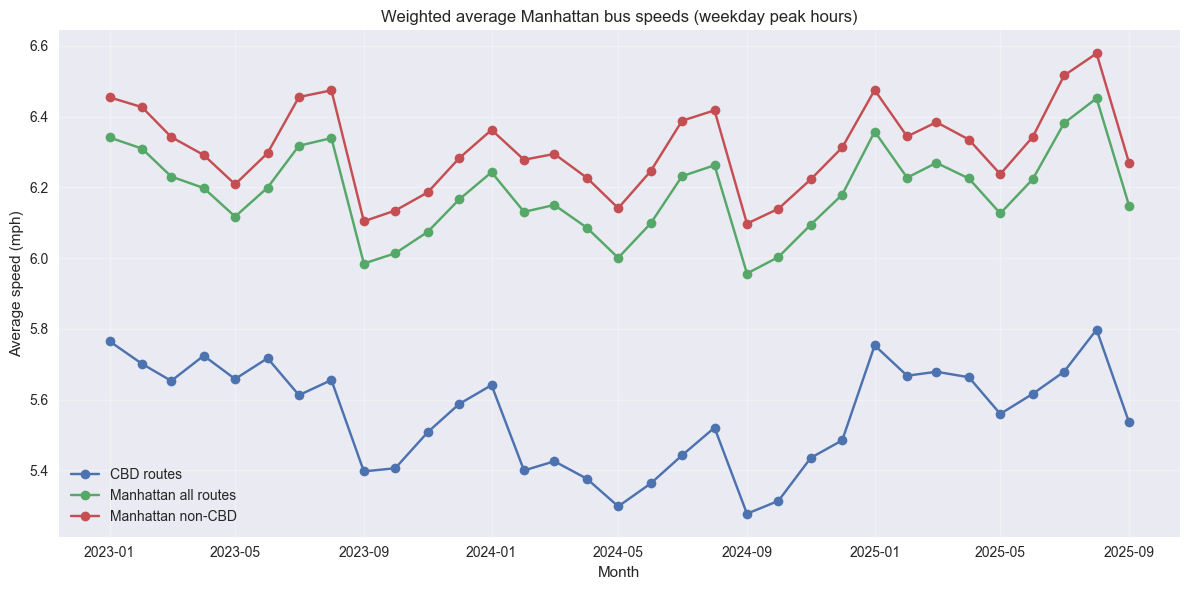

In [23]:
plt.figure(figsize=(12, 6))
for group_name, subset in group_monthly.sort_values("month_start").groupby("group"):
    plt.plot(subset["month_start"], subset["avg_speed_mph"], marker="o", label=group_name)
plt.title("Weighted average Manhattan bus speeds (weekday peak hours)")
plt.xlabel("Month")
plt.ylabel("Average speed (mph)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
yearly_panel = (
    monthly_panel.groupby(["route_id", "year", "treatment", "group"], as_index=False)
    .agg(
        total_distance=("total_distance", "sum"),
        weighted_speed=("weighted_speed", "sum")
    )
)
yearly_panel["avg_speed_mph"] = yearly_panel["weighted_speed"] / yearly_panel["total_distance"]
yearly_summary = (
    yearly_panel.groupby(["group", "year"], as_index=False)
    .agg(
        total_distance=("total_distance", "sum"),
        weighted_speed=("weighted_speed", "sum")
    )
)
yearly_summary["avg_speed_mph"] = yearly_summary["weighted_speed"] / yearly_summary["total_distance"]
yearly_summary_pivot = yearly_summary.pivot(index="group", columns="year", values="avg_speed_mph")
yearly_summary, yearly_summary_pivot

(               group  year  total_distance  weighted_speed  avg_speed_mph
 0         CBD routes  2023      614445.196    3.450974e+06       5.616406
 1         CBD routes  2024      613764.216    3.324086e+06       5.415901
 2         CBD routes  2025      461197.551    2.611138e+06       5.661647
 3  Manhattan non-CBD  2023     3105976.937    1.958627e+07       6.305992
 4  Manhattan non-CBD  2024     3071634.284    1.923093e+07       6.260813
 5  Manhattan non-CBD  2025     2351323.591    1.502282e+07       6.389093,
 year                   2023      2024      2025
 group                                          
 CBD routes         5.616406  5.415901  5.661647
 Manhattan non-CBD  6.305992  6.260813  6.389093)

In [25]:
yoy_changes = yearly_summary_pivot.assign(
    delta_2023_2024=lambda df: df.get(2024) - df.get(2023),
    delta_2024_2025=lambda df: df.get(2025) - df.get(2024)
 )[["delta_2023_2024", "delta_2024_2025"]]
yoy_changes

year,delta_2023_2024,delta_2024_2025
group,,
CBD routes,-0.200505,0.245746
Manhattan non-CBD,-0.045179,0.128280


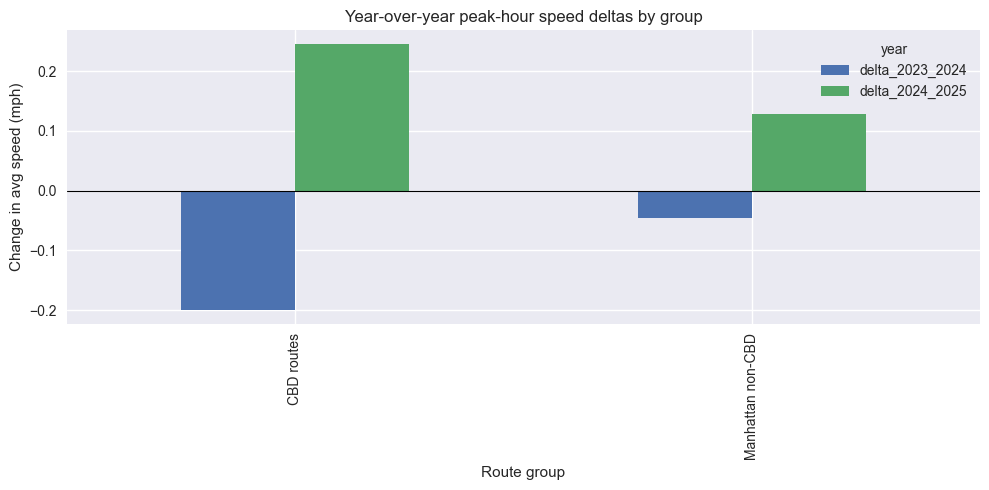

In [26]:
ax = yoy_changes.plot(kind="bar", figsize=(10, 5))
ax.set_title("Year-over-year peak-hour speed deltas by group")
ax.set_ylabel("Change in avg speed (mph)")
ax.set_xlabel("Route group")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Ridership context
Combine ridership with speed trends to see whether passenger volumes shifted alongside speeds.

In [27]:
ridership_panel = (
    ridership.assign(
        bus_route=lambda df: df["bus_route"].astype(str).str.upper().str.strip(),
        transit_timestamp=lambda df: pd.to_datetime(df["transit_timestamp"]),
    )
    .query("bus_route.str.startswith('M')", engine="python")
    .loc[lambda df: df["weekend"] == 0]
    .assign(
        month_start=lambda df: df["transit_timestamp"].dt.to_period("M").dt.to_timestamp(),
    )
    .groupby(["bus_route", "month_start"], as_index=False)["total_ridership"]
    .sum()
 )
ridership_monthly = ridership_panel.groupby("month_start", as_index=False)["total_ridership"].sum()
ridership_monthly.head()

,month_start,total_ridership
0,2023-01-01,5173400
1,2023-02-01,4935404
2,2023-03-01,5945396
3,2023-04-01,5161553
4,2023-05-01,6032390


/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_51331/12548132.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


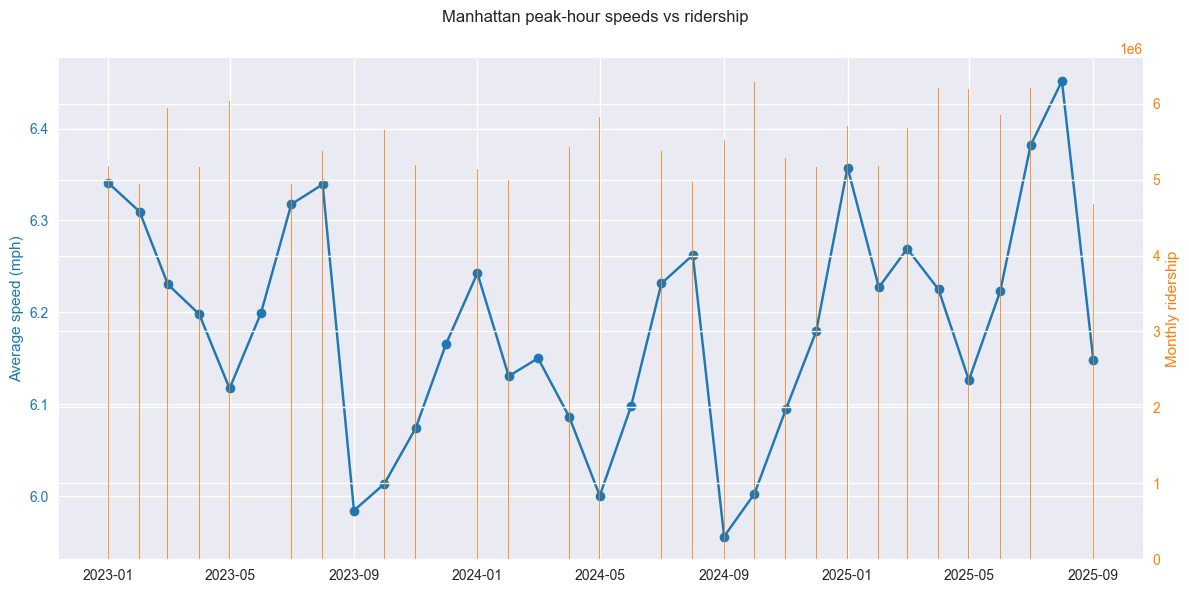

In [35]:
speed_ridership = (
    overall_monthly[["month_start", "avg_speed_mph"]].rename(columns={"avg_speed_mph": "avg_speed_manhattan"})
    .merge(ridership_monthly, on="month_start", how="inner")
    .sort_values("month_start")
)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(speed_ridership["month_start"], speed_ridership["avg_speed_manhattan"], color="tab:blue", marker="o", label="Avg speed (mph)")
ax1.set_ylabel("Average speed (mph)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.bar(speed_ridership["month_start"], speed_ridership["total_ridership"], alpha=0.8, color="tab:orange", label="Total ridership")
ax2.set_ylabel("Monthly ridership", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
fig.suptitle("Manhattan peak-hour speeds vs ridership")
fig.tight_layout()
fig.show()

### Mapping CBD route performance
We approximate route centroids from timepoint coordinates to recreate the folium view comparing current speeds.

In [29]:
cbd_2025 = manhattan_peak.loc[(manhattan_peak["treatment"] == 1) & (manhattan_peak["year"] == 2025)].copy()
cbd_route_summary = (
    cbd_2025.groupby("route_id", as_index=False)
    .agg(
        total_distance=("weight_distance", "sum"),
        weighted_speed=("weighted_speed", "sum"),
        lat_mean=("timepoint_stop_latitude", "mean"),
        lon_mean=("timepoint_stop_longitude", "mean")
    )
)
cbd_route_summary["avg_speed_mph"] = cbd_route_summary["weighted_speed"] / cbd_route_summary["total_distance"]
center = [cbd_route_summary["lat_mean"].mean(), cbd_route_summary["lon_mean"].mean()]
m = folium.Map(location=center, zoom_start=11)
speed_min, speed_max = cbd_route_summary["avg_speed_mph"].min(), cbd_route_summary["avg_speed_mph"].max()
norm = mcolors.Normalize(vmin=speed_min, vmax=speed_max)
cmap = cm.get_cmap("viridis")
for _, row in cbd_route_summary.iterrows():
    color = mcolors.to_hex(cmap(norm(row["avg_speed_mph"])))
    folium.CircleMarker(
        location=(row["lat_mean"], row["lon_mean"]),
        radius=6,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(f"{row['route_id']}: {row['avg_speed_mph']:.2f} mph", max_width=200)
    ).add_to(m)
m

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_51331/3066183880.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


---
## Difference-in-Differences Regression
We replicate the core regression from the production pipeline, comparing CBD routes against other Manhattan routes. The outcome is the change in average speed, and we contrast 2023→2024 vs. 2024→2025 shifts.

In [30]:
speed_changes = yearly_panel.sort_values(["route_id", "year"]).copy()
speed_changes["speed_change"] = speed_changes.groupby("route_id")["avg_speed_mph"].diff()
speed_changes = speed_changes[speed_changes["year"].isin([2024, 2025])].dropna(subset=["speed_change"])
speed_changes["post"] = (speed_changes["year"] == 2025).astype(int)
speed_changes["period_label"] = np.where(speed_changes["post"] == 1, "2024→2025", "2023→2024")
speed_changes.head()

,route_id,year,treatment,group,total_distance,weighted_speed,avg_speed_mph,speed_change,post,period_label
1,M1,2024,0,Manhattan non-CBD,173441.115,1.004128e+06,5.789445,-0.018636,0,2023→2024
2,M1,2025,0,Manhattan non-CBD,125538.120,7.373869e+05,5.873808,0.084363,1,2024→2025
4,M10,2024,0,Manhattan non-CBD,75628.167,4.246764e+05,5.615320,0.005897,0,2023→2024
5,M10,2025,0,Manhattan non-CBD,56378.106,3.254635e+05,5.772871,0.157551,1,2024→2025
7,M100,2024,0,Manhattan non-CBD,125392.322,7.448940e+05,5.940507,-0.066530,0,2023→2024


In [31]:
weights = speed_changes["total_distance"].clip(lower=0.001)
did_model = smf.wls("speed_change ~ post * treatment + C(route_id)", data=speed_changes, weights=weights).fit()
did_model.summary().tables[0]

Dep. Variable:,speed_change,R-squared:,0.627
Model:,WLS,Adj. R-squared:,0.227
Method:,Least Squares,F-statistic:,1.566
Date:,"Sat, 08 Nov 2025",Prob (F-statistic):,0.0774
Time:,12:23:15,Log-Likelihood:,60.632
No. Observations:,84,AIC:,-33.26
Df Residuals:,40,BIC:,73.69
Df Model:,43,,
Covariance Type:,nonrobust,,


In [32]:
interaction_term = "post:treatment"
coef = did_model.params[interaction_term]
p_value = did_model.pvalues[interaction_term]
conf_int = did_model.conf_int().loc[interaction_term]
did_summary = {
    "DiD coefficient (mph)": coef,
    "p-value": p_value,
    "95% CI lower": conf_int[0],
    "95% CI upper": conf_int[1],
    "R-squared": did_model.rsquared,
    "Adj. R-squared": did_model.rsquared_adj,
    "Observations": int(did_model.nobs),
}
pd.Series(did_summary)

DiD coefficient (mph)     0.257738
p-value                   0.006904
95% CI lower              0.074871
95% CI upper              0.440604
R-squared                 0.627415
Adj. R-squared            0.226887
Observations             84.000000
dtype: float64

In [33]:
group_change_summary = (
    speed_changes.groupby(["group", "period_label"], as_index=False)
    .agg(
        weighted_speed_change=("speed_change", "mean"),
        total_routes=("route_id", "nunique")
    )
)
group_change_summary.pivot(index="group", columns="period_label", values="weighted_speed_change")

period_label,2023→2024,2024→2025
group,,
CBD routes,-0.18627,0.247370
Manhattan non-CBD,-0.06880,0.165601


In [34]:
did_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.0545,0.079,-0.688,0.495,-0.214,0.105
C(route_id)[T.M10],0.0447,0.140,0.319,0.752,-0.239,0.328
C(route_id)[T.M100],-0.0258,0.119,-0.216,0.830,-0.267,0.215
C(route_id)[T.M101],0.0591,0.106,0.556,0.581,-0.156,0.274
C(route_id)[T.M102],0.0017,0.128,0.013,0.990,-0.258,0.261
C(route_id)[T.M103],-0.0024,0.135,-0.018,0.986,-0.274,0.269
C(route_id)[T.M104],-0.0235,0.139,-0.169,0.867,-0.305,0.258
C(route_id)[T.M106],0.0440,0.205,0.215,0.831,-0.371,0.459
C(route_id)[T.M11],-0.0538,0.122,-0.441,0.661,-0.300,0.193
C(route_id)[T.M116],-0.0705,0.150,-0.469,0.641,-0.374,0.233


### Interpretation checklist
- Confirm the DiD interaction captures the incremental CBD change between the two periods.\n- Validate residual assumptions if you extend the model (normality, leverage).\n- Swap in alternative control groups (e.g., SBS routes) by tweaking the `treatment` flag.